> **Nota:** este notebook es material exploratorio/pedagógico del mini-proyecto original del equipo. La implementación oficial y reproducible del análisis vive en `src/` (ver el README principal del repositorio) — se corre con `python run_pipeline.py` desde la raíz del repositorio. Este notebook se conserva porque documenta cómo se llegó a los primeros hallazgos, pero los resultados citables son los de `src/` y `outputs/`.

---

# Miniproyecto Ciclo de Vida Empresas a Nivel Nacional

**Integrantes:**
* Ignacio Hidalgo: redacción de conclusiones, recomendaciones y revisión de coherencia
* Sergio Rebolledo: exploración estadística y análisis de correlaciones
* Avelyn García: carga, limpieza y unión de las fuentes de datos
* Todos: construcción y revisión de visualizaciones


## Contexto

Usamos datos públicos del Servicio de Impuestos Internos (SII) sobre el ciclo de vida de las empresas en Chile, disponibles en su sección de estadísticas de inicio de actividades. Combinamos tres fuentes:

* **Actividades inscritas:** registra cuándo un contribuyente inicia o amplía una actividad económica ante el SII (aperturas).
* **Término de giro (TG):** registra cuándo un contribuyente comunica formalmente el cierre de su actividad (cierres).
* **PUB_COMU_RUBR:** base agregada por año, comuna y rubro económico (2005-2024) con número de empresas activas, ventas, trabajadores dependientes y a honorarios, entre otras variables.

Las tres fuentes comparten la misma granularidad — año, comuna y rubro económico (clasificación CIIU) — lo que permite cruzarlas directamente sin necesidad de hacer matching adicional.

Nos interesa esta base porque cubre 20 años de historia (2005-2024) a nivel nacional, con desagregación geográfica (347 comunas, 17 regiones) y sectorial (22 rubros), lo que permite estudiar el comportamiento del tejido empresarial chileno con un nivel de detalle que normalmente no está disponible al público: no solo cuántas empresas hay, sino cuántas nacen, cuántas cierran, cuántos trabajadores emplean y cómo varía todo eso entre sectores y en el tiempo. Es decir, la base necesaria para responder preguntas de concentración, competencia, crecimiento y estabilidad del emprendimiento a nivel país.

## Preguntas a responder

1. ¿Cuál es la concentración promedio de empresas por combinación comuna-rubro a nivel nacional, y qué combinaciones concentran más empresas?
2. ¿Existe correlación entre la concentración de empresas (competencia) y su tasa de cierre, a nivel nacional?
3. ¿Existe correlación entre la concentración de empresas (competencia) y su tasa de cierre, tanto a nivel nacional de cada rubro por separado?
4. ¿Cómo evolucionó el número de aperturas y cierres de empresas a nivel nacional entre 2005 y 2024?
5. ¿Los rubros con más concentración de empresas son también los más volátiles (menos estables) en el tiempo, o la relación es al revés?

## Instalación e inicialización

In [ ]:
# Instalar pyxlsb para abrir archivo
!pip install pyxlsb

In [ ]:
# Importar librerias

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import re
import unicodedata
from pyxlsb import open_workbook
from scipy import stats


In [ ]:
# Ruta a los archivos de datos (relativa a este notebook).
# Estos archivos NO vienen incluidos en el repositorio (ver ../data/README.md para la
# fuente oficial del SII, la fecha de descarga y dónde guardarlos): colocar aquí, sueltos
# (no dentro de un .zip), PUB_actividades_inscritas.txt, PUB_TG.txt y PUB_COMU_RUBR.xlsb.
DATA_DIR = Path("../data/raw")

if DATA_DIR.exists():
    print("Contenido de la carpeta:")
    print(list(DATA_DIR.iterdir()))
else:
    print(f"No se encontró la carpeta en: {DATA_DIR} -- ver ../data/README.md")


In [ ]:
archivo_actividad = DATA_DIR / "PUB_actividades_inscritas.txt"
archivo_termino = DATA_DIR / "PUB_TG.txt"
archivo_comuna_rubro = DATA_DIR / "PUB_COMU_RUBR.xlsb"

## Carga y limpieza de datos

En esta sección cargamos los datos e immediatamente los limpiamos unificando el formato de las categorias de los rubros, parseando los recuentos y seleccionando las columnas Año Comercial, Comuna, Rubro y Recuento para los datos.  

### Funciones necesarias para limpiar los datos

In [ ]:
def normalizar_rubro(texto: str) -> str:
    """Deja comparable el mismo rubro entre archivos con formato distinto:
    'A - Agricultura, ganadería...' y 'AGRICULTURA, GANADERIA...' -> misma clave.
    Quita el código de letra inicial, tildes, y pasa a mayúsculas."""
    texto = re.sub(r"^[A-Z]\s*-\s*", "", str(texto).strip())
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    return texto.upper().strip()

In [ ]:
# Carga y limpieza del dataset termino de giro
df = pd.read_csv(archivo_termino, sep="\t", encoding="latin-1", dtype=str)

df = df.dropna(subset=["Año comercial"])  # descarta filas 100% vacías
df = df[df["Rubro"].str.strip() != "Valor por Defecto"]

df["año"] = df["Año comercial"].astype(int)
df["comuna"] = df["Comuna"].str.strip().str.upper()
df["rubro"] = df["Rubro"].apply(normalizar_rubro)

# Parsear recuento
df["cierres"] = df["Recuento"].str.replace(".", "", regex=False).astype(int)
df_cierres = df.copy()

df_cierres = df_cierres.groupby(["año", "comuna", "rubro"], as_index=False)["cierres"].sum()
df_cierres.head()


    año     comuna                                              rubro  cierres
0  2005      AISÉN               ACTIVIDADES FINANCIERAS Y DE SEGUROS        1
1  2005      AISÉN       AGRICULTURA, GANADERIA, SILVICULTURA Y PESCA        1
2  2005      AISÉN  COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...        3
3  2005      AISÉN                        TRANSPORTE Y ALMACENAMIENTO        1
4  2005  ALGARROBO  ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y D...        1

In [ ]:
# Carga y limpieza del dataset de aperturas
df = pd.read_csv(archivo_actividad, sep="\t", encoding="latin-1", dtype=str)

df = df[df["RUBRO"].str.strip() != "Valor por Defecto"]

df["año"] = df["Año comercial"].astype(int)

# Parsear recuento
df["aperturas"] = df["Recuento"].str.replace(".", "", regex=False).astype(int)
df["comuna"] = df["Comuna"].str.strip().str.upper()
df["rubro"] = df["RUBRO"].apply(normalizar_rubro)

df_aperturas = df.copy()

df_aperturas = df_aperturas.groupby(["año", "comuna", "rubro"], as_index=False)["aperturas"].sum()
df_aperturas.head()


    año comuna                                              rubro  aperturas
0  2005  AISÉN  ACTIVIDADES ARTISTICAS, DE ENTRETENIMIENTO Y R...         25
1  2005  AISÉN  ACTIVIDADES DE ALOJAMIENTO Y DE SERVICIO DE CO...         54
2  2005  AISÉN  ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y D...         27
3  2005  AISÉN  ACTIVIDADES DE SERVICIOS ADMINISTRATIVOS Y DE ...         98
4  2005  AISÉN               ACTIVIDADES FINANCIERAS Y DE SEGUROS         11

El DataFrame `df_empresas` se crea a partir del archivo `PUB_COMU_RUBR.xlsb`. Contiene el número de empresas activas por año, comuna y rubro. La `NameError` que viste anteriormente indica que esta variable no estaba definida cuando intentaste usarla. A continuación, se presenta el código para cargarlo y limpiarlo.

In [ ]:
filas = []
with open_workbook(archivo_comuna_rubro) as wb, wb.get_sheet(1) as sheet:
    for i, row in enumerate(sheet.rows()):
        if i < 5:
            continue
        año, comuna, rubro, n_empresas = row[0].v, row[1].v, row[4].v, row[5].v
        if año is None or comuna is None or rubro is None:
            continue
        if rubro == "Sin información" or comuna == "Sin Información":
            continue
        filas.append((int(año), str(comuna).strip().upper(), normalizar_rubro(rubro), n_empresas or 0))

df = pd.DataFrame(filas, columns=["año", "comuna", "rubro", "empresas_activas"])

df_empresas = df.copy()
df_empresas = df_empresas.groupby(["año", "comuna", "rubro"], as_index=False)["empresas_activas"].sum()
df_empresas.head()

    año comuna                                              rubro  \
0  2005  AISÉN  ACTIVIDADES ARTISTICAS, DE ENTRETENIMIENTO Y R...   
1  2005  AISÉN  ACTIVIDADES DE ALOJAMIENTO Y DE SERVICIO DE CO...   
2  2005  AISÉN  ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y D...   
3  2005  AISÉN  ACTIVIDADES DE SERVICIOS ADMINISTRATIVOS Y DE ...   
4  2005  AISÉN               ACTIVIDADES FINANCIERAS Y DE SEGUROS   

   empresas_activas  
0               5.0  
1              92.0  
2               1.0  
3              24.0  
4               3.0  

In [ ]:
# Cargamos y limpiamos el archivo con las empresas abiertas por comuna, año y rubro
filas = []
with open_workbook(archivo_comuna_rubro) as wb, wb.get_sheet(1) as sheet:
    for i, row in enumerate(sheet.rows()):
        if i < 5:
            continue
        año, comuna, rubro, n_empresas = row[0].v, row[1].v, row[4].v, row[5].v
        if año is None or comuna is None or rubro is None:
            continue
        if rubro == "Sin información" or comuna == "Sin Información":
            continue
        filas.append((int(año), str(comuna).strip().upper(), normalizar_rubro(rubro), n_empresas or 0))

df = pd.DataFrame(filas, columns=["año", "comuna", "rubro", "empresas_activas"])

df_empresas = df.copy()
df_empresas = df_empresas.groupby(["año", "comuna", "rubro"], as_index=False)["empresas_activas"].sum()
df_empresas.head()

    año comuna                                              rubro  \
0  2005  AISÉN  ACTIVIDADES ARTISTICAS, DE ENTRETENIMIENTO Y R...   
1  2005  AISÉN  ACTIVIDADES DE ALOJAMIENTO Y DE SERVICIO DE CO...   
2  2005  AISÉN  ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y D...   
3  2005  AISÉN  ACTIVIDADES DE SERVICIOS ADMINISTRATIVOS Y DE ...   
4  2005  AISÉN               ACTIVIDADES FINANCIERAS Y DE SEGUROS   

   empresas_activas  
0               5.0  
1              92.0  
2               1.0  
3              24.0  
4               3.0  

### Unificar fuentes

Unificamos la información en un sola tabla.

In [ ]:
# Unir fuentes

df_unificado = df_aperturas.merge(df_cierres, on=["año", "comuna", "rubro"], how="outer")
df_unificado = df_unificado.merge(df_empresas, on=["año", "comuna", "rubro"], how="outer")

for col in ["aperturas", "cierres", "empresas_activas"]:
    df_unificado[col] = df_unificado[col].fillna(0).astype(int)

# Tasa de cierre: cierres del año / empresas activas ese mismo año.
# Con empresas_activas = 0 la tasa queda indefinida (NaN), no se fuerza a 0.
denom = df_unificado["empresas_activas"].astype(float).replace(0, float("nan"))
df_unificado["tasa_cierre"] = (df_unificado["cierres"] / denom).round(4)

df_unificado.sort_values(["año", "comuna", "rubro"]).reset_index(drop=True)
df_unificado.head()

    año comuna                                              rubro  aperturas  \
0  2005  AISÉN  ACTIVIDADES ARTISTICAS, DE ENTRETENIMIENTO Y R...         25   
1  2005  AISÉN  ACTIVIDADES DE ALOJAMIENTO Y DE SERVICIO DE CO...         54   
2  2005  AISÉN  ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y D...         27   
3  2005  AISÉN  ACTIVIDADES DE SERVICIOS ADMINISTRATIVOS Y DE ...         98   
4  2005  AISÉN               ACTIVIDADES FINANCIERAS Y DE SEGUROS         11   

   cierres  empresas_activas  tasa_cierre  
0        0                 5       0.0000  
1        0                92       0.0000  
2        0                 1       0.0000  
3        0                24       0.0000  
4        1                 3       0.3333  

## Pregunta 1: ¿Cuál es la concentración promedio de empresas por combinación comuna-rubro a nivel nacional, y qué combinaciones concentran más empresas?

In [ ]:
# Promedio de empresas activas para cada combinación comuna-rubro
concentracion_combinacion = (
    df_empresas
    .groupby(["comuna", "rubro"], as_index=False)
    .agg(concentracion_promedio=("empresas_activas", "mean"))
)

# Promedio nacional de todas las combinaciones
promedio_nacional = concentracion_combinacion["concentracion_promedio"].mean()

print(
    "Concentración promedio nacional por combinación comuna-rubro:",
    f"{promedio_nacional:,.1f} empresas"
)

# Diez combinaciones con mayor concentración
top_combinaciones = concentracion_combinacion.nlargest(
    10, "concentracion_promedio"
)

print("\nCombinaciones con mayor concentración promedio:")
print(top_combinaciones.round(1).to_string(index=False))

Concentración promedio nacional por combinación comuna-rubro: 170.3 empresas

Combinaciones con mayor concentración promedio:
      comuna                                                                                    rubro  concentracion_promedio
    SANTIAGO COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACION DE VEHICULOS AUTOMOTORES Y MOTOCICLETAS                 21071.9
  LAS CONDES                                                     ACTIVIDADES FINANCIERAS Y DE SEGUROS                 11778.2
 PROVIDENCIA COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACION DE VEHICULOS AUTOMOTORES Y MOTOCICLETAS                 10715.4
  LAS CONDES COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACION DE VEHICULOS AUTOMOTORES Y MOTOCICLETAS                  9353.2
  LAS CONDES                                        ACTIVIDADES PROFESIONALES, CIENTIFICAS Y TECNICAS                  8392.4
 PUENTE ALTO COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACION DE VEHICULOS AUTOMOTORES Y MOTOCICLETAS                 

### Grafico Concentración Promedio

In [ ]:
#Colores
COLOR_POS = "#1F5C8B"     # confirma la hipótesis
COLOR_NEG = "#C2632A"     # invierte la hipótesis
COLOR_NS = "#B9C7CE"      # no significativo
COLOR_BG = "#F6F8FA"
COLOR_GRID = "#D2DEE4"
COLOR_INK = "#16222B"
COLOR_INK_SOFT = "#52697A"
plt.rcParams.update({
        "figure.facecolor": COLOR_BG, "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": COLOR_GRID, "axes.labelcolor": COLOR_INK_SOFT,
        "text.color": COLOR_INK, "xtick.color": COLOR_INK_SOFT, "ytick.color": COLOR_INK_SOFT,
        "grid.color": COLOR_GRID, "font.family": "sans-serif",
    })


In [ ]:
def acortar(texto: str, n: int = 42) -> str:
    return texto if len(texto) <= n else texto[: n - 1] + "…"

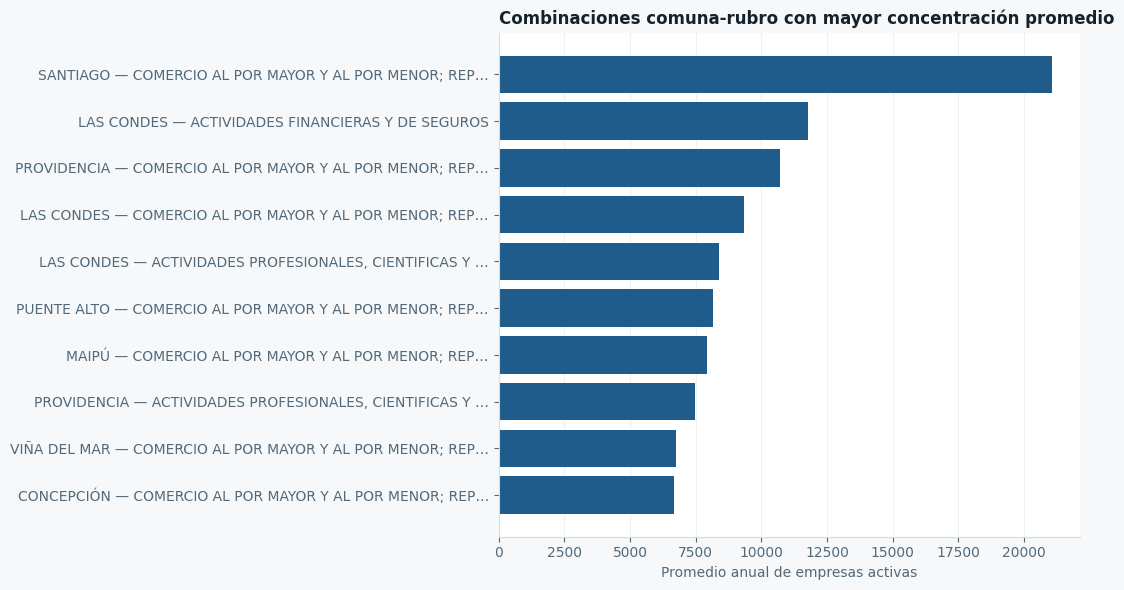

In [ ]:
top_grafico = top_combinaciones.sort_values("concentracion_promedio")

etiquetas = (
    top_grafico["comuna"]
    + " — "
    + top_grafico["rubro"].apply(acortar)
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    etiquetas,
    top_grafico["concentracion_promedio"],
    color=COLOR_POS
)

ax.set_xlabel("Promedio anual de empresas activas")
ax.set_title(
    "Combinaciones comuna-rubro con mayor concentración promedio",
    loc="left",
    fontweight="bold"
)
ax.grid(axis="x", alpha=0.4)
ax.set_axisbelow(True)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()

## Analisis correlación

In [ ]:
agg = df_unificado.groupby(["comuna", "rubro"], as_index=False).agg(
        aperturas_total=("aperturas", "sum"),
        cierres_total=("cierres", "sum"),
        empresa_años=("empresas_activas", "sum"),  # suma de "empresas activas" a través de los 20 años = exposición total
        concentracion_promedio=("empresas_activas", "mean"),  # tamaño típico del rubro en esa comuna
    )
    # Tasa de cierre por "empresa-año" de exposición — más robusta que promediar tasas anuales.
agg["tasa_cierre"] = agg["cierres_total"] / agg["empresa_años"]
agg.head()


  comuna                                              rubro  aperturas_total  \
0  AISÉN  ACTIVIDADES ARTISTICAS, DE ENTRETENIMIENTO Y R...              971   
1  AISÉN  ACTIVIDADES DE ALOJAMIENTO Y DE SERVICIO DE CO...             2227   
2  AISÉN  ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y D...              972   
3  AISÉN  ACTIVIDADES DE LOS HOGARES COMO EMPLEADORES; A...                2   
4  AISÉN  ACTIVIDADES DE ORGANIZACIONES Y ORGANOS EXTRAT...                3   

   cierres_total  empresa_años  concentracion_promedio  tasa_cierre  
0             16           266                   13.30     0.060150  
1            161          3215                  160.75     0.050078  
2             15           302                   15.10     0.049669  
3              0             0                    0.00          NaN  
4              0             0                    0.00          NaN  

## Pregunta 2: ¿Existe correlación entre la concentración de empresas (competencia) y su tasa de cierre, a nivel nacional?

In [ ]:
MIN_EMPRESA_ANIOS = 200 # umbral mínimo de exposición para evitar ruido de muestras chicas
muestra = agg[agg["empresa_años"] >= MIN_EMPRESA_ANIOS].copy()

pearson_r, pearson_p = stats.pearsonr(muestra["concentracion_promedio"], muestra["tasa_cierre"])
spearman_r, spearman_p = stats.spearmanr(muestra["concentracion_promedio"], muestra["tasa_cierre"])

print(f"Combinaciones comuna+rubro totales: {len(agg):,}")
print(f"Combinaciones con exposición suficiente (>= {MIN_EMPRESA_ANIOS} empresa-años): {len(muestra):,}")
print()
print("Correlación entre concentración (nº empresas activas) y tasa de cierre:")
print(f"  Pearson  r = {pearson_r:+.4f}  (p = {pearson_p:.4g})")
print(f"  Spearman r = {spearman_r:+.4f}  (p = {spearman_p:.4g})")

Combinaciones comuna+rubro totales: 7,064
Combinaciones con exposición suficiente (>= 200 empresa-años): 3,932

Correlación entre concentración (nº empresas activas) y tasa de cierre:
  Pearson  r = -0.0282  (p = 0.07682)
  Spearman r = +0.0293  (p = 0.06625)


## Pregunta 3: ¿Existe correlación entre la concentración de empresas (competencia) y su tasa de cierre, tanto a nivel nacional de cada rubro por separado?

In [ ]:
# Segmentación
p75_conc = muestra["concentracion_promedio"].quantile(0.75)
p75_cierre = muestra["tasa_cierre"].quantile(0.75)
p25_conc = muestra["concentracion_promedio"].quantile(0.25)

print(f"\nUmbrales usados — concentración alta: >p75 ({p75_conc:.0f} empresas); tasa de cierre alta: >p75 ({p75_cierre:.4f})")

saturados = muestra[(muestra["concentracion_promedio"] > p75_conc) & (muestra["tasa_cierre"] > p75_cierre)]
saludables = muestra[(muestra["concentracion_promedio"] > p75_conc) & (muestra["tasa_cierre"] <= p75_cierre)]
nicho_bajo = muestra[muestra["concentracion_promedio"] <= p25_conc]

print(f"\n1) SATURADOS Y RIESGOSOS (alta concentración + alta tasa de cierre): {len(saturados)} combinaciones")
print(saturados.nlargest(8, "tasa_cierre")[["comuna", "rubro", "concentracion_promedio", "tasa_cierre"]].to_string(index=False))

print(f"\n2) CONCENTRADOS Y SALUDABLES (alta concentración + baja tasa de cierre): {len(saludables)} combinaciones")
print(saludables.nsmallest(8, "tasa_cierre")[["comuna", "rubro", "concentracion_promedio", "tasa_cierre"]].to_string(index=False))

print(f"\n3) BAJA CONCENTRACIÓN (posible espacio de entrada, con la salvedad del tamaño chico de muestra): {len(nicho_bajo)} combinaciones")
print(nicho_bajo.nsmallest(5, "tasa_cierre")[["comuna", "rubro", "concentracion_promedio", "tasa_cierre"]].to_string(index=False))




Umbrales usados — concentración alta: >p75 (230 empresas); tasa de cierre alta: >p75 (0.0570)

1) SATURADOS Y RIESGOSOS (alta concentración + alta tasa de cierre): 187 combinaciones
    comuna                          rubro  concentracion_promedio  tasa_cierre
  COQUIMBO OTRAS ACTIVIDADES DE SERVICIOS                  486.70     0.325457
 LA SERENA OTRAS ACTIVIDADES DE SERVICIOS                  591.70     0.270661
  CONCHALÍ OTRAS ACTIVIDADES DE SERVICIOS                  291.80     0.266621
TALCAHUANO OTRAS ACTIVIDADES DE SERVICIOS                  317.85     0.265219
 QUILICURA OTRAS ACTIVIDADES DE SERVICIOS                  353.80     0.263991
  PUDAHUEL OTRAS ACTIVIDADES DE SERVICIOS                  396.60     0.251765
     MAIPÚ OTRAS ACTIVIDADES DE SERVICIOS                 1181.05     0.247068
     RENCA OTRAS ACTIVIDADES DE SERVICIOS                  233.50     0.241113

2) CONCENTRADOS Y SALUDABLES (alta concentración + baja tasa de cierre): 796 combinaciones
       comuna 

In [ ]:
resultados = []
min_comunas = 30
for rubro, grupo in agg[agg["empresa_años"] >= 50].groupby("rubro"):
    if len(grupo) < min_comunas:
        continue
    r, p = stats.spearmanr(grupo["concentracion_promedio"], grupo["tasa_cierre"])
    resultados.append({"rubro": rubro, "n_comunas": len(grupo), "spearman_r": r, "p_valor": p})

df_corr = pd.DataFrame(resultados).sort_values("spearman_r", ascending=True)
print(f"\n--- Correlación concentración~cierre POR RUBRO (controlando por sector) ---")
print(f"({min_comunas}+ comunas por rubro, 50+ empresa-años de exposición por combinación)\n")
print(f"Tamaño de la muestra {len(resultados)}")
print(df_corr.to_string(index=False))




--- Correlación concentración~cierre POR RUBRO (controlando por sector) ---
(30+ comunas por rubro, 50+ empresa-años de exposición por combinación)

Tamaño de la muestra 19
                                                                                     rubro  n_comunas  spearman_r      p_valor
                                              AGRICULTURA, GANADERIA, SILVICULTURA Y PESCA        341   -0.268020 5.078008e-07
                         ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y DE ASISTENCIA SOCIAL        223   -0.245160 2.181418e-04
                                                      ACTIVIDADES FINANCIERAS Y DE SEGUROS        247   -0.141133 2.655908e-02
                                                                                 ENSENANZA        261   -0.108790 7.937345e-02
                                                            OTRAS ACTIVIDADES DE SERVICIOS        331    0.035333 5.217808e-01
                                         ACTIVIDADES PROFESIONAL

### Gráfico correlación concentración y cierre

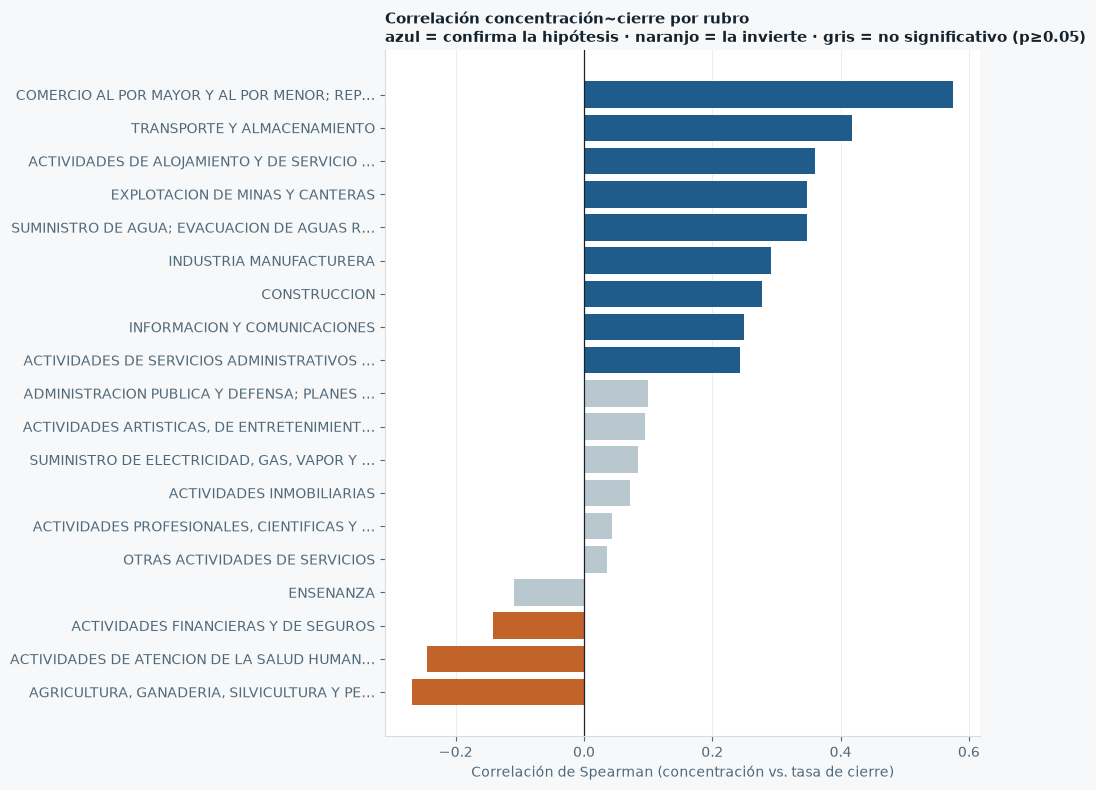

In [ ]:
df = df_corr
colores = [
        COLOR_NS if p >= 0.05 else (COLOR_POS if r > 0 else COLOR_NEG)
        for r, p in zip(df["spearman_r"], df["p_valor"])
    ]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df["rubro"].apply(acortar), df["spearman_r"], color=colores)
ax.axvline(0, color=COLOR_INK, linewidth=0.9)
ax.set_xlabel("Correlación de Spearman (concentración vs. tasa de cierre)")
ax.set_title(
        "Correlación concentración~cierre por rubro\n"
        "azul = confirma la hipótesis · naranjo = la invierte · gris = no significativo (p≥0.05)",
        fontsize=10.5, color=COLOR_INK, fontweight="bold", loc="left",
    )
ax.grid(axis="x", alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()

## Pregunta 4: ¿Cómo evolucionó el número de aperturas y cierres de empresas a nivel nacional entre 2005 y 2024?

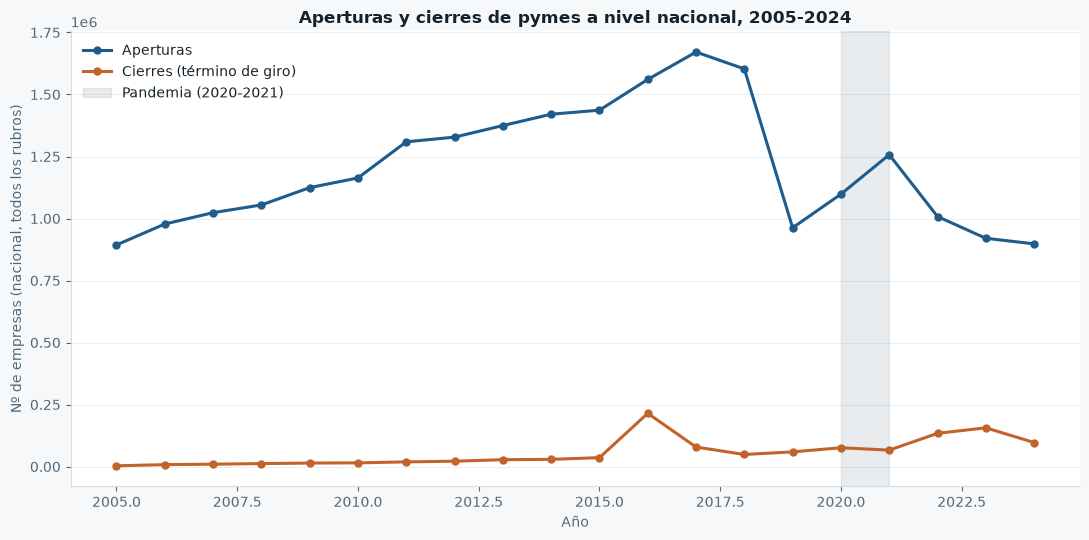

In [ ]:
df = df_unificado
anual = df.groupby("año", as_index=False)[["aperturas", "cierres"]].sum()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(anual["año"], anual["aperturas"], marker="o", color=COLOR_POS, linewidth=2.2, markersize=5, label="Aperturas")
ax.plot(anual["año"], anual["cierres"], marker="o", color=COLOR_NEG, linewidth=2.2, markersize=5, label="Cierres (término de giro)")
ax.axvspan(2020, 2021, color=COLOR_INK_SOFT, alpha=0.12, label="Pandemia (2020-2021)")
ax.set_xlabel("Año")
ax.set_ylabel("Nº de empresas (nacional, todos los rubros)")
ax.set_title("Aperturas y cierres de pymes a nivel nacional, 2005-2024", color=COLOR_INK, fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()

## Pregunta 5: ¿Los rubros con más concentración de empresas son también los más volátiles (menos estables) en el tiempo, o la relación es al revés?

In [ ]:
#Crecimiento historico y estabilidad
filas_cre = []
with open_workbook(archivo_comuna_rubro) as wb, wb.get_sheet(1) as sheet:
    for i, row in enumerate(sheet.rows()):
        if i < 5:
            continue
        año, comuna, rubro, n_empresas = row[0].v, row[1].v, row[4].v, row[5].v
        trab_ponderados, trab_honorarios = row[9].v, row[18].v
        if año is None or comuna is None or rubro is None:
            continue
        if rubro == "Sin información" or comuna == "Sin Información":
            continue
        filas_cre.append((
            int(año), normalizar_rubro(rubro),
            n_empresas or 0, trab_ponderados or 0, trab_honorarios or 0,
        ))

df_cre = pd.DataFrame(filas_cre, columns=["año", "rubro", "empresas_activas", "trab_ponderados", "trab_honorarios"])
df_cre["trab_total"] = df_cre["trab_ponderados"] + df_cre["trab_honorarios"]

nat = df_cre.groupby(["año", "rubro"], as_index=False)[["empresas_activas", "trab_total"]].sum()
pivot_cre = nat.pivot(index="rubro", columns="año", values="trab_total")

cagr = (pivot_cre[2024] / pivot_cre[2005]) ** (1/19) - 1        # crecimiento historico
volatilidad = pivot_cre.pct_change(axis=1).std(axis=1)          # estabilidad

resumen_crecimiento_estabilidad = pd.DataFrame({
    "CAGR_%": (cagr * 100).round(2),
    "volatilidad_%": (volatilidad * 100).round(2),
}).sort_values("CAGR_%", ascending=False)

resumen_crecimiento_estabilidad

                                                    CAGR_%  volatilidad_%
rubro                                                                    
SUMINISTRO DE AGUA; EVACUACION DE AGUAS RESIDUA...    7.50          12.87
ACTIVIDADES DE ATENCION DE LA SALUD HUMANA Y DE...    7.07           7.94
ACTIVIDADES DE LOS HOGARES COMO EMPLEADORES; AC...    6.52            NaN
ACTIVIDADES DE SERVICIOS ADMINISTRATIVOS Y DE A...    6.36          10.58
ADMINISTRACION PUBLICA Y DEFENSA; PLANES DE SEG...    5.66           8.92
ACTIVIDADES DE ALOJAMIENTO Y DE SERVICIO DE COM...    5.62          11.79
ACTIVIDADES ARTISTICAS, DE ENTRETENIMIENTO Y RE...    5.59          19.95
ACTIVIDADES PROFESIONALES, CIENTIFICAS Y TECNICAS     5.59          13.88
TRANSPORTE Y ALMACENAMIENTO                           5.26           7.37
EXPLOTACION DE MINAS Y CANTERAS                       5.23          14.59
ENSENANZA                                             5.05           9.97
INFORMACION Y COMUNICACIONES          

### Gráfico Crecimiento Historico

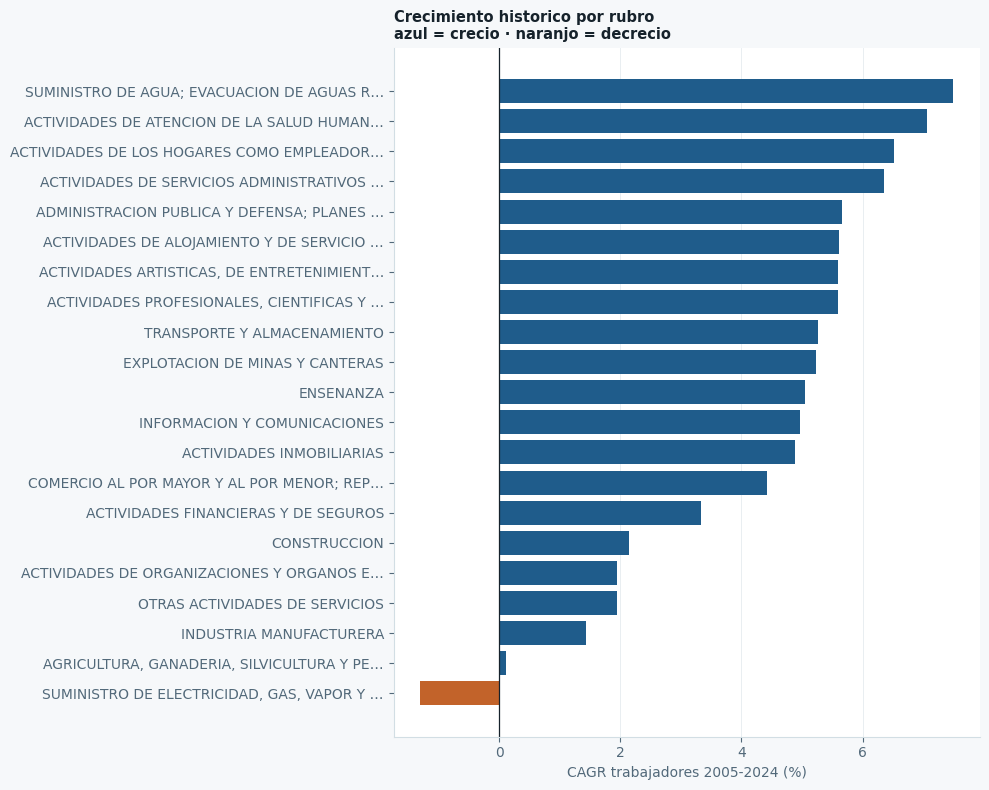

In [ ]:
# Grafico de crecimiento historico
df = resumen_crecimiento_estabilidad.sort_values("CAGR_%", ascending=True)
colores = [COLOR_NEG if v < 0 else COLOR_POS for v in df["CAGR_%"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df.index.map(acortar), df["CAGR_%"], color=colores)
ax.axvline(0, color=COLOR_INK, linewidth=0.9)
ax.set_xlabel("CAGR trabajadores 2005-2024 (%)")
ax.set_title(
    "Crecimiento historico por rubro\n"
    "azul = crecio · naranjo = decrecio",
    fontsize=10.5, color=COLOR_INK, fontweight="bold", loc="left",
)
ax.grid(axis="x", alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()

### Gráfico Estabilidad

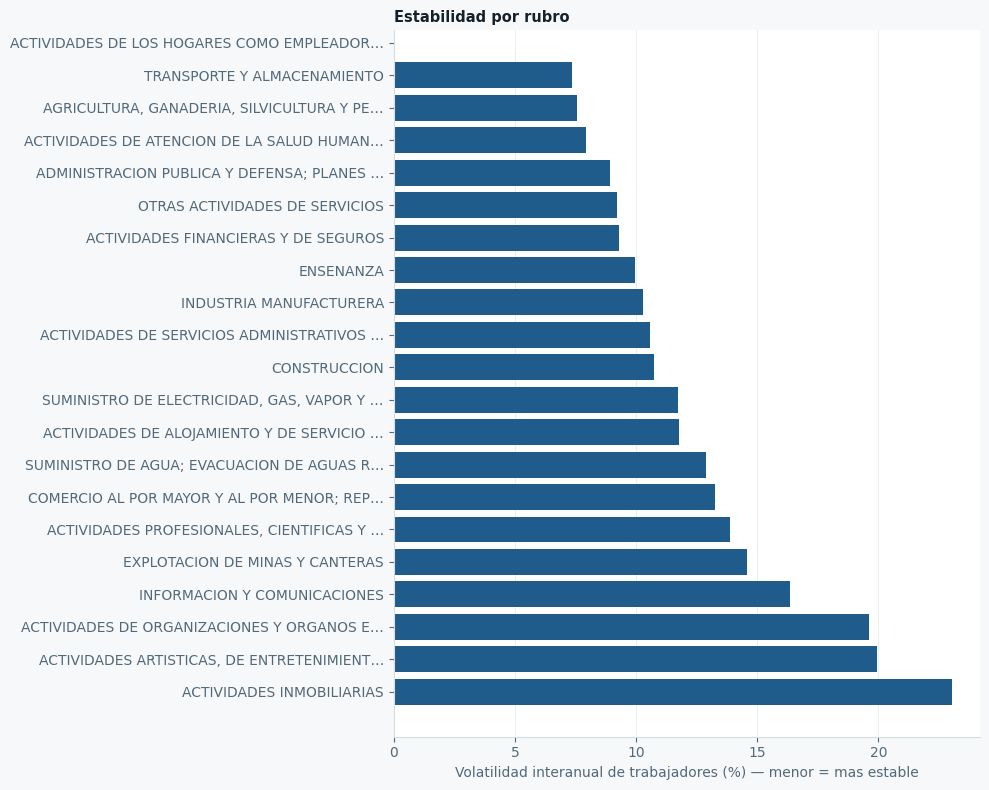

In [ ]:
# Grafico de estabilidad
df = resumen_crecimiento_estabilidad.sort_values("volatilidad_%", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df.index.map(acortar), df["volatilidad_%"], color=COLOR_POS)
ax.set_xlabel("Volatilidad interanual de trabajadores (%) — menor = mas estable")
ax.set_title(
    "Estabilidad por rubro",
    fontsize=10.5, color=COLOR_INK, fontweight="bold", loc="left",
)
ax.grid(axis="x", alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()

## **Conclusiones**




1. Concentración de empresas por rubro

El gráfico muestra que Comercio no solo concentra la mayor cantidad de empresas activas, sino que supera ampliamente al segundo rubro, Transporte, llegando a ser aproximadamente tres veces mayor. Esto refleja que el emprendimiento en Chile está fuertemente concentrado en actividades comerciales.

Una posible explicación es que el comercio presenta menores barreras de entrada en comparación con otros sectores, ya que generalmente requiere menos infraestructura especializada y puede comenzar con un capital relativamente bajo. Por lo tanto, los datos sugieren que, en la práctica, una parte importante de las personas que emprenden en Chile opta por actividades comerciales.



2. Evolución de aperturas y cierres entre 2005 y 2024

La cantidad de aperturas presenta variaciones relativamente acotadas durante el período, mientras que la serie de cierres presenta algunos cambios que requieren una interpretación más cuidadosa.

El primer quiebre importante ocurre en 2016, cuando los cierres alcanzan 214.705, una cifra considerablemente superior a la tendencia de los años anteriores. Este aumento no coincide con una crisis económica relevante de ese período, por lo que resulta razonable considerar que pudo estar relacionado con algún proceso administrativo del SII, como la regularización de empresas que mantenían actividades registradas pese a haber dejado de operar.

En cambio, el aumento observado entre 2022 y 2023 presenta características diferentes. Los cierres aumentan de manera sostenida durante ambos años, lo que podría estar relacionado con los efectos posteriores a la pandemia y con el término de algunas medidas de apoyo que permitieron a muchas empresas mantenerse activas durante 2020 y 2021.

Por lo tanto, la serie no debería interpretarse simplemente como una tendencia permanente al aumento de los cierres. Los datos parecen mostrar dos situaciones distintas: un quiebre posiblemente asociado a un proceso administrativo en 2016 y otro aumento que podría representar un fenómeno económico más cercano a la realidad de las empresas después de la pandemia.



3. Relación entre concentración y cierres por rubro

Este análisis es probablemente uno de los resultados más interesantes, porque no confirma completamente la hipótesis inicial de que una mayor concentración de empresas necesariamente genera más cierres.

La relación sí es bastante clara en Comercio (r=0,58) y Transporte (r=0,42), dos de los rubros con mayor cantidad de empresas. En estos sectores existe una mayor similitud entre los negocios, por lo que una concentración elevada puede significar una competencia más fuerte y, en consecuencia, una mayor probabilidad de cierre.

Sin embargo, Agricultura presenta una relación negativa (r=-0,27). Es decir, en este caso, las comunas con mayor concentración de empresas agrícolas tienden a presentar menos cierres. Esto puede explicarse porque la concentración agrícola no necesariamente representa saturación del mercado, sino que puede estar relacionada con condiciones favorables para la actividad, como disponibilidad de agua, calidad del suelo o cercanía a mercados.

Esto muestra que la concentración empresarial no tiene el mismo significado en todos los sectores. En algunos rubros puede representar una mayor competencia, mientras que en otros puede ser una señal de que existen condiciones favorables para desarrollar la actividad.



4. Crecimiento histórico por rubro

El crecimiento observado en Salud y en Suministro de agua y gestión de desechos parece responder principalmente a factores estructurales y no solamente a cambios de corto plazo en la demanda.

En el caso de Salud, factores como el envejecimiento de la población y una mayor demanda de servicios pueden ayudar a explicar su crecimiento. En Suministro de agua y gestión de desechos, el aumento también puede estar relacionado con una mayor cobertura de servicios y con exigencias ambientales y regulatorias cada vez mayores.

Por otro lado, Electricidad y gas presenta una disminución más marcada. Esto puede estar relacionado con las características del sector, que requiere altos niveles de inversión y presenta una fuerte regulación. Además, el crecimiento de una actividad no necesariamente implica un aumento proporcional de trabajadores, especialmente cuando existen procesos de automatización y mejoras en la eficiencia.



5. Concentración y estabilidad empresarial

Al relacionar la concentración de empresas con la volatilidad, se obtuvo una correlación débil y no significativa (r=-0,36; p=0,11). A primera vista, esto podría indicar que no existe una relación clara entre ambas variables a nivel nacional.

Sin embargo, el análisis por rubro permite entender mejor este resultado. Como vimos anteriormente, la relación entre concentración y cierres cambia dependiendo de la actividad económica. Mientras algunos rubros presentan una relación positiva, otros presentan una relación negativa.

Al reunir todos los sectores en un único indicador nacional, estas diferencias terminan compensándose entre sí y hacen que la relación general sea mucho más débil. Por eso, resulta más útil analizar la relación entre concentración y estabilidad de manera específica para cada rubro, en lugar de utilizar solamente un indicador agregado.

## **Recomendaciones**


Los resultados muestran que el comercio tiene una participación muy elevada dentro del conjunto de empresas activas y, al mismo tiempo, presenta una relación relativamente fuerte entre concentración y cierres (r=0,58). Esto sugiere que las políticas de apoyo al emprendimiento podrían considerar con mayor atención el rubro en el que se desarrolla cada nuevo negocio.

En lugar de concentrar el apoyo únicamente en aumentar la cantidad de nuevos emprendimientos, podría ser conveniente orientar parte de los recursos hacia sectores donde existan mejores condiciones para la permanencia de las empresas, como actividades relacionadas con recursos productivos locales, salud o servicios de saneamiento.

También sería importante interpretar con cuidado el aumento de los cierres observado en la serie histórica. El quiebre de 2016 debería analizarse de manera separada, ya que podría estar relacionado con un proceso administrativo y no necesariamente con un deterioro real de la actividad empresarial. En cambio, el aumento registrado durante 2022 y 2023 merece mayor atención debido a su posible relación con los efectos posteriores a la pandemia.

Finalmente, la relación entre concentración y cierres por rubro podría utilizarse como un criterio adicional para diseñar políticas de apoyo a las empresas. Un programa que entregue apoyo de manera general a todos los emprendimientos puede tener resultados muy diferentes dependiendo del sector y de las condiciones existentes en cada comuna. Considerar estas diferencias permitiría identificar con mayor precisión dónde existe una mayor exposición al cierre y dónde la concentración empresarial puede representar, por el contrario, una señal de especialización y mejores condiciones productivas.

